In [5]:
import numpy as np

from factors import *

In [10]:
bt = BackTester(fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate'],
                instrument_type='futures_continuous_contract',
                instrument_id_list = ['C0', 'FG0'],
                fc_freq = '1d',
                start_time='20230101',
                end_time='20260310',
                portfolio_adjust_method = '1D',
                interest_method = 'compound',
                risk_free_rate=False,
                n_jobs = 5
                )
# bt.backtest()

In [11]:
bt.data

,time,instrument_id,open,high,low,close,volume,position
0,2023-01-03,C0,2829,2842,2817,2840,301325,705314
1,2023-01-04,C0,2840,2877,2838,2875,489218,711148
2,2023-01-05,C0,2875,2882,2859,2878,341944,714472
3,2023-01-06,C0,2873,2892,2867,2886,368002,731213
4,2023-01-09,C0,2882,2895,2879,2890,306730,744645
...,...,...,...,...,...,...,...,...
1531,2026-03-04,FG0,1055,1055,1037,1038,985426,1321021
1532,2026-03-05,FG0,1039,1065,1038,1055,1177512,1263360
1533,2026-03-06,FG0,1056,1093,1052,1087,1384174,1256461
1534,2026-03-09,FG0,1098,1163,1090,1104,3221862,1165149


In [4]:
# self = bt
# Data = self.data
# df = Data.copy()
#
# df = df.sort_values(by='time', ascending=True)
# df = df.set_index(['time', 'instrument_id'])
#
# fc_class_list = [resolve_factor_class(fc_name) for fc_name in self.fc_name_list]
# f = lambda x: get_factor_value_for_one_factor(df, x)
#
# with Parallel(n_jobs=self.n_jobs) as parallel:
#     mapper_list = parallel(delayed(f)(fc_class) for fc_class in fc_class_list)
# mapper_list = [x.reset_index() for x in mapper_list]

In [12]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_20',
 'fac_winrate_30']

In [16]:
df = bt.data.copy()

In [20]:
def _get_fee_for_instrument(Data: pd.DataFrame) -> float:
    instrument_ids = Data['instrument_id'].dropna().unique().tolist()
    if len(instrument_ids) != 1:
        raise ValueError('Fee lookup expects data of one instrument only.')
    instrument_id = instrument_ids[0]
    if instrument_id not in FEE:
        raise ValueError(f'Missing fee config for instrument_id={instrument_id}. Please update utils/params.py FEE.')
    return float(FEE[instrument_id])
fee = _get_fee_for_instrument(df)
fc_col = bt.fc_name_with_param_list
fee

0.0002

In [14]:
bt.performance_dc['C0']['fac_cumret_1_50']['daily_gross_ret'].copy()

,time,fac_cumret_1_50
0,2023-01-03,0.000000
1,2023-01-04,0.000152
2,2023-01-05,-0.000005
3,2023-01-06,0.000017
4,2023-01-09,0.000012
...,...,...
763,2026-03-04,0.000003
764,2026-03-05,0.000005
765,2026-03-06,0.000004
766,2026-03-09,-0.000001


In [25]:
df[fc_col].ffill().fillna(0)

,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_20,fac_winrate_30
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.083333,1.083333,0.0,0.00,0.000000
1,0.012324,0.012324,0.000000,0.000000,0.000000,0.000000,9.791667,9.791667,0.0,0.00,0.000000
2,0.006684,0.006684,0.013380,0.013380,0.000000,0.000000,6.673611,6.673611,0.0,0.00,0.000000
3,0.005382,0.005382,0.008603,0.008603,0.016197,0.016197,5.796875,5.796875,0.0,0.00,0.000000
4,0.004383,0.004383,0.007125,0.007125,0.010707,0.010707,5.504167,5.504167,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
763,0.001284,0.000963,0.002494,0.001910,0.003793,0.002928,11.836190,4.978093,0.7,0.65,0.566667
764,0.001550,0.000924,0.002837,0.001892,0.004044,0.002835,10.236190,5.525712,0.7,0.70,0.600000
765,0.001680,0.001049,0.003232,0.001979,0.004516,0.002943,10.852857,5.697239,0.7,0.70,0.600000
766,0.001660,0.001132,0.003343,0.002185,0.004893,0.003112,11.419524,5.976933,0.8,0.75,0.633333


In [4]:
bt.ts_performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Turnover,TS IC,TS RankIC,T-corr,count,all,Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.000428,0.000414,0.000202,0.000200,2.119748,2.070893,4.667747,4.546063,0.000118,0.000120,...,0.000272,0.142099,0.129478,15.556349,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
2024,0.000193,0.000185,0.000150,0.000150,1.286048,1.233117,1.569669,1.537650,0.000069,0.000070,...,0.000158,0.095230,0.104134,15.556349,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
2025,0.000131,0.000125,0.000095,0.000095,1.379965,1.316451,2.023482,1.963745,0.000060,0.000060,...,0.000123,0.090319,0.071158,15.588457,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
2026,0.000507,0.000500,0.000105,0.000104,4.849837,4.788807,13.730050,13.135739,0.000014,0.000014,...,0.000142,0.120841,0.023077,6.403124,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
all,0.000264,0.000255,0.000153,0.000152,1.727439,1.676176,2.786738,2.744100,0.000118,0.000120,...,0.000182,0.127282,0.122591,768.000000,NaN,NaN,fac_cumret_1_50,1d,0.0002,C0
2023,0.000321,0.000311,0.000176,0.000174,1.827750,1.792389,5.622437,5.460965,0.000062,0.000063,...,0.000200,0.129049,0.102794,15.556349,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0
2024,0.000081,0.000077,0.000120,0.000120,0.673209,0.640900,0.728309,0.710385,0.000080,0.000081,...,0.000077,0.029468,0.058797,15.556349,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0
2025,0.000029,0.000025,0.000057,0.000057,0.505681,0.442142,0.704264,0.620189,0.000051,0.000052,...,0.000073,0.032093,0.041798,15.588457,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0
2026,0.000259,0.000255,0.000047,0.000047,5.537018,5.473941,14.955109,14.593159,0.000007,0.000007,...,0.000068,0.056945,0.145598,6.403124,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0


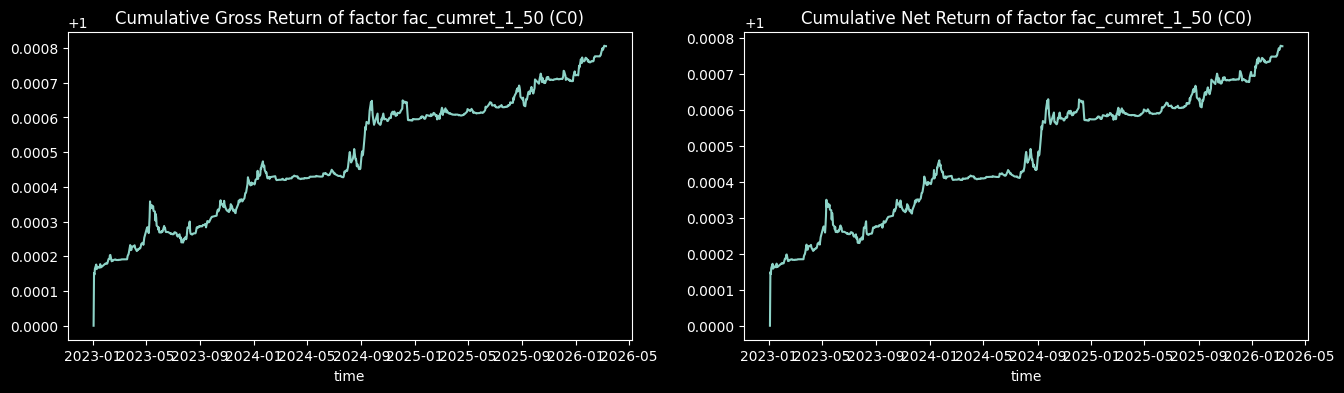

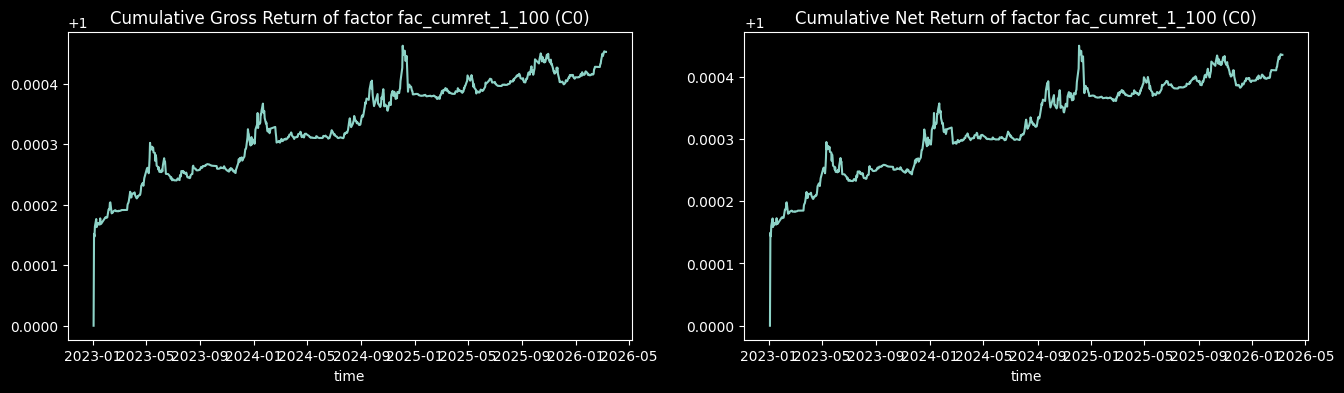

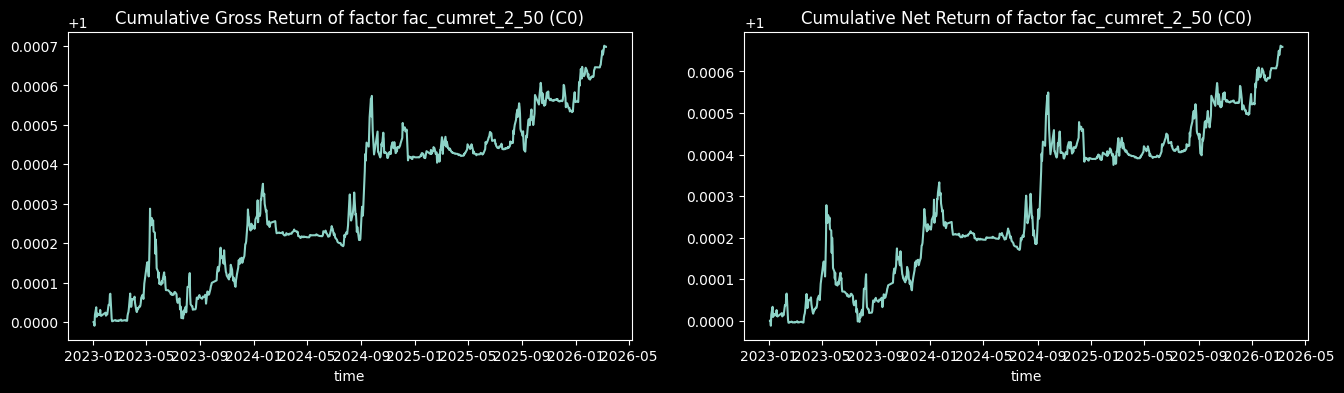

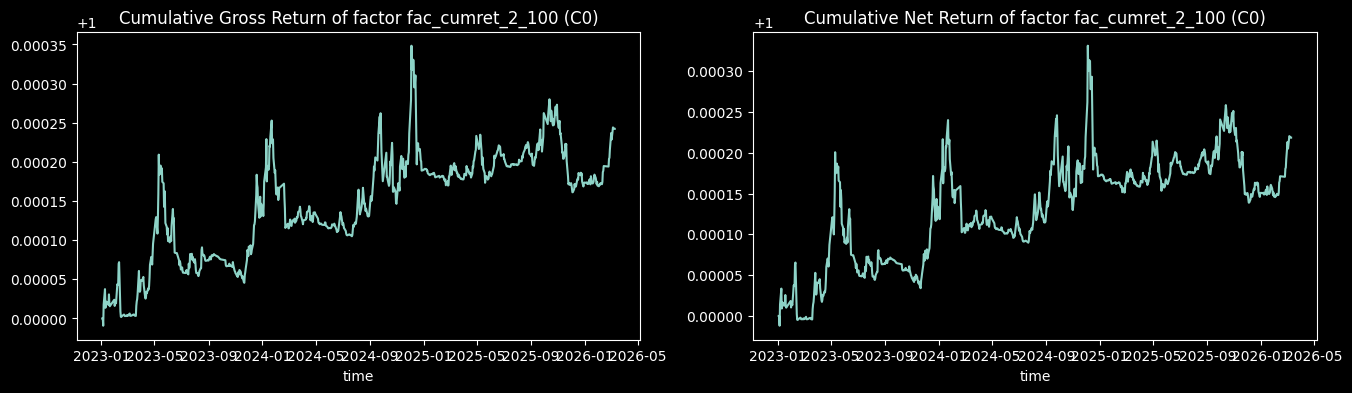

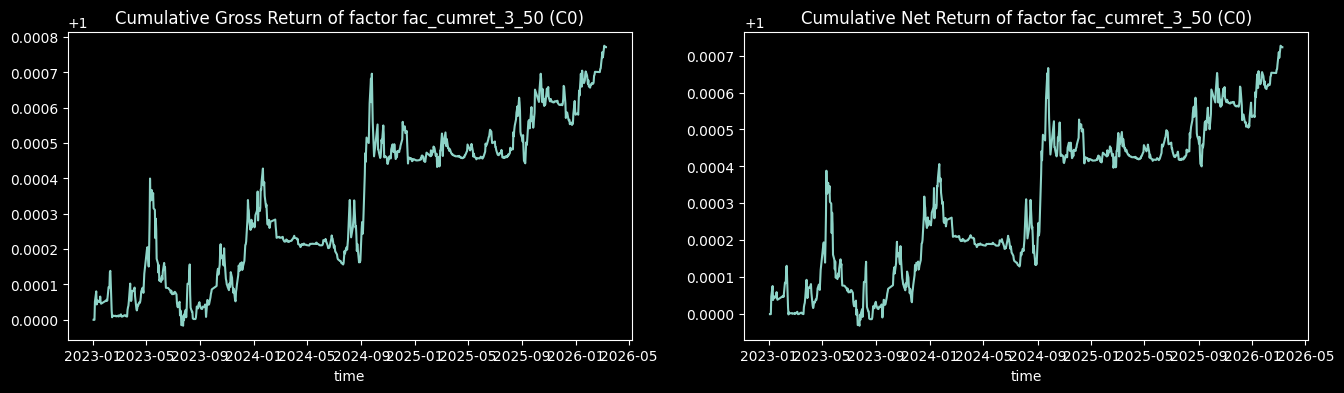

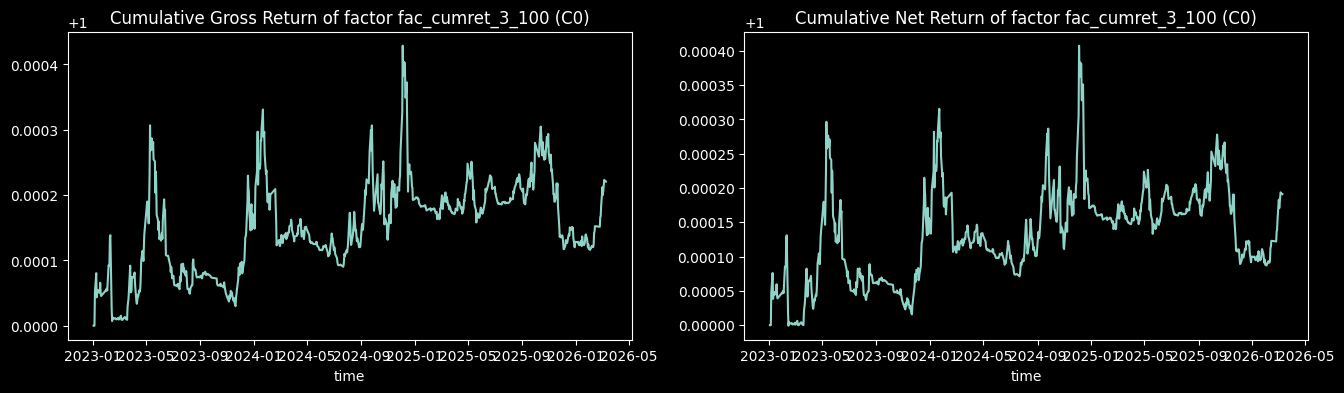

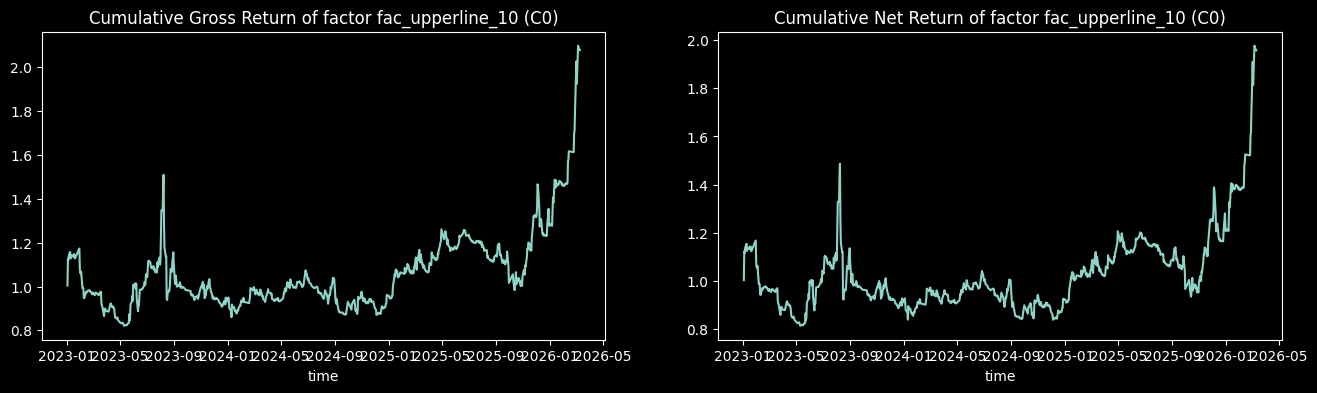

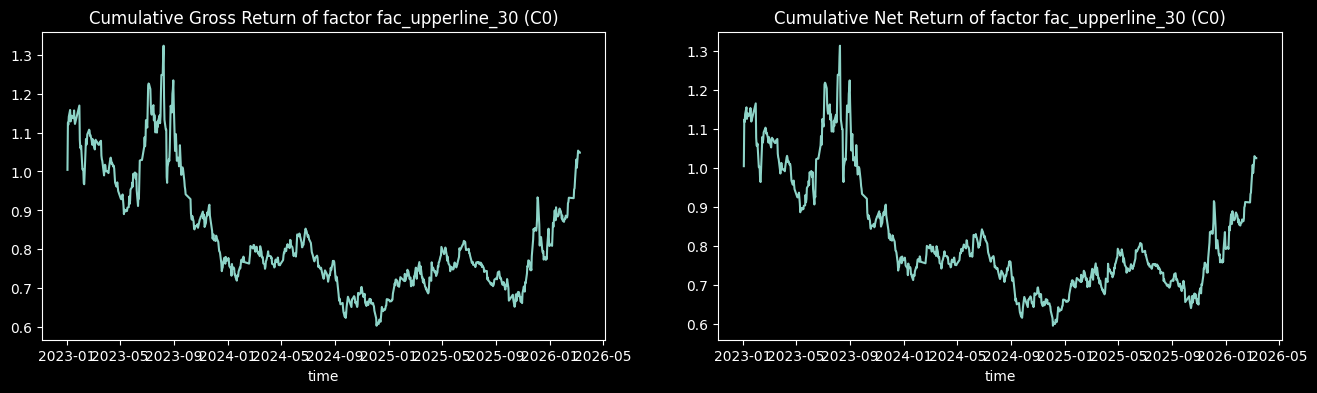

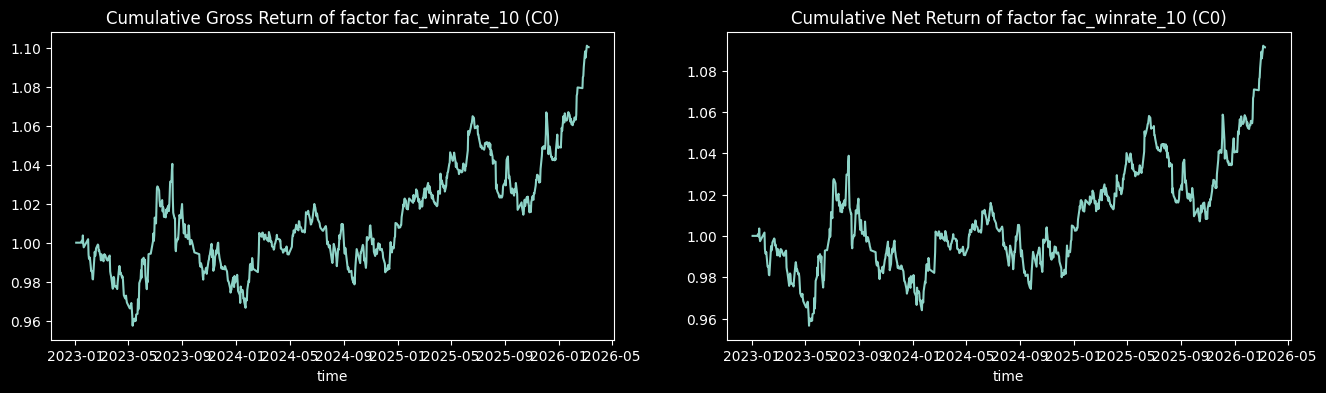

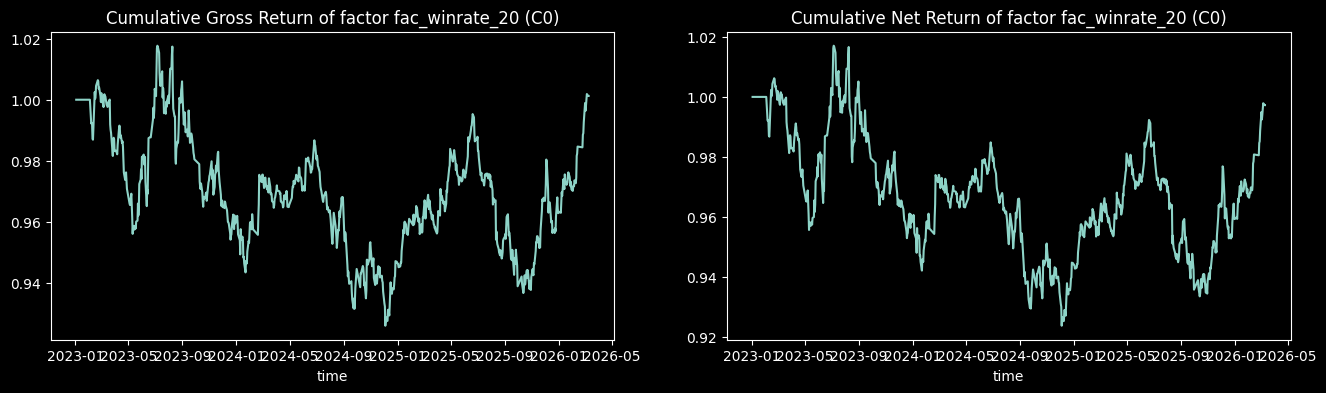

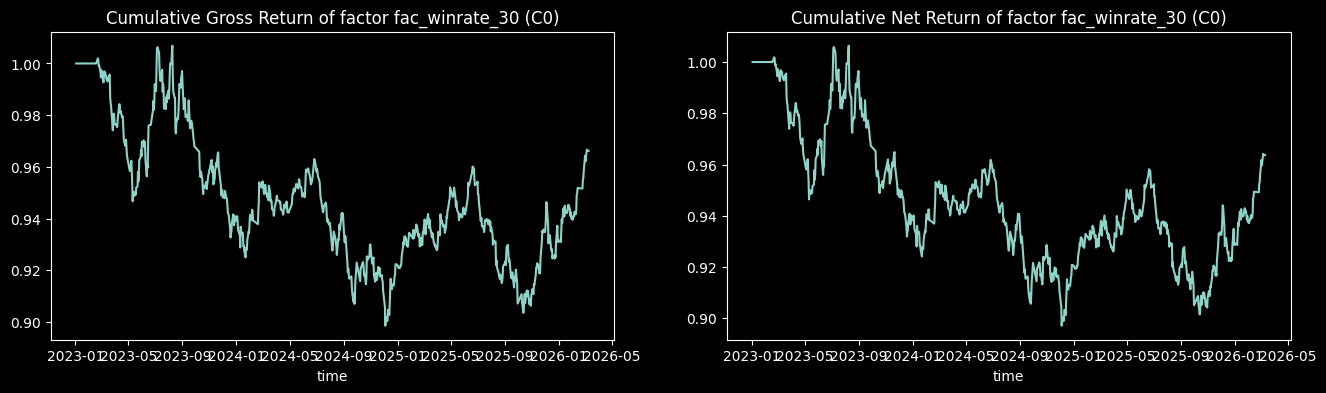

In [3]:
bt.plot_nav()

In [1]:
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, \
    load_robot_execution_failures
download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

In [2]:
print(timeseries.head())

   id  time  F_x  F_y  F_z  T_x  T_y  T_z
0   1     0   -1   -1   63   -3   -1    0
1   1     1    0    0   62   -3   -1    0
2   1     2   -1   -1   61   -3    0    0
3   1     3   -1   -1   63   -2   -1    0
4   1     4   -1   -1   63   -3   -1    0


In [3]:
from tsfresh import extract_features
extracted_features = extract_features(timeseries, column_id="id", column_sort="time")

Feature Extraction: 100%|██████████| 20/20 [00:22<00:00,  1.14s/it]


In [4]:
timeseries

,id,time,F_x,F_y,F_z,T_x,T_y,T_z
0,1,0,-1,-1,63,-3,-1,0
1,1,1,0,0,62,-3,-1,0
2,1,2,-1,-1,61,-3,0,0
3,1,3,-1,-1,63,-2,-1,0
4,1,4,-1,-1,63,-3,-1,0
...,...,...,...,...,...,...,...,...
1315,88,10,-10,2,39,-21,-24,5
1316,88,11,-11,2,38,-24,-22,6
1317,88,12,-12,3,23,-24,-24,5
1318,88,13,-13,4,26,-29,-27,5


In [5]:
extracted_features

,F_x__variance_larger_than_standard_deviation,F_x__has_duplicate_max,F_x__has_duplicate_min,F_x__has_duplicate,F_x__sum_values,F_x__abs_energy,F_x__mean_abs_change,F_x__mean_change,F_x__mean_second_derivative_central,F_x__median,...,T_z__fourier_entropy__bins_5,T_z__fourier_entropy__bins_10,T_z__fourier_entropy__bins_100,T_z__permutation_entropy__dimension_3__tau_1,T_z__permutation_entropy__dimension_4__tau_1,T_z__permutation_entropy__dimension_5__tau_1,T_z__permutation_entropy__dimension_6__tau_1,T_z__permutation_entropy__dimension_7__tau_1,T_z__query_similarity_count__query_None__threshold_0.0,T_z__mean_n_absolute_max__number_of_maxima_7
1,0.0,0.0,1.0,1.0,-14.0,14.0,0.142857,0.000000,-0.038462,-1.0,...,NaN,NaN,NaN,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,NaN,0.000000
2,0.0,1.0,1.0,1.0,-13.0,25.0,1.000000,0.000000,-0.038462,-1.0,...,1.073543,1.494175,2.079442,0.937156,1.234268,1.540306,1.748067,1.831020,NaN,0.571429
3,0.0,0.0,1.0,1.0,-10.0,12.0,0.714286,0.000000,-0.038462,-1.0,...,1.386294,1.732868,2.079442,1.265857,1.704551,2.019815,2.163956,2.197225,NaN,0.571429
4,0.0,1.0,1.0,1.0,-6.0,16.0,1.214286,-0.071429,-0.038462,0.0,...,1.073543,1.494175,2.079442,1.156988,1.907284,2.397895,2.302585,2.197225,NaN,1.000000
5,0.0,0.0,0.0,1.0,-9.0,17.0,0.928571,-0.071429,0.038462,-1.0,...,0.900256,1.320888,2.079442,1.156988,1.863680,2.271869,2.302585,2.197225,NaN,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,1.0,1.0,0.0,1.0,-1073.0,96833.0,7.142857,-5.428571,-0.038462,-98.0,...,0.735622,0.735622,1.386294,1.585771,2.253858,2.397895,2.302585,2.197225,NaN,24.285714
85,1.0,0.0,1.0,1.0,143.0,1683.0,1.357143,1.071429,0.076923,8.0,...,0.735622,0.735622,1.667462,1.332245,1.589027,1.893788,2.163956,2.197225,NaN,5.571429
86,1.0,0.0,0.0,0.0,961.0,83497.0,9.071429,9.071429,0.807692,52.0,...,0.735622,1.073543,1.732868,0.687092,0.983088,1.159589,1.227529,1.303092,NaN,9.285714
87,1.0,1.0,0.0,1.0,4509.0,1405437.0,12.928571,12.214286,-1.038462,338.0,...,0.735622,0.735622,1.386294,0.535961,0.836988,1.159589,1.497866,1.581094,NaN,40.285714


In [6]:
extracted_features.columns

Index(['F_x__variance_larger_than_standard_deviation',
       'F_x__has_duplicate_max', 'F_x__has_duplicate_min',
       'F_x__has_duplicate', 'F_x__sum_values', 'F_x__abs_energy',
       'F_x__mean_abs_change', 'F_x__mean_change',
       'F_x__mean_second_derivative_central', 'F_x__median',
       ...
       'T_z__fourier_entropy__bins_5', 'T_z__fourier_entropy__bins_10',
       'T_z__fourier_entropy__bins_100',
       'T_z__permutation_entropy__dimension_3__tau_1',
       'T_z__permutation_entropy__dimension_4__tau_1',
       'T_z__permutation_entropy__dimension_5__tau_1',
       'T_z__permutation_entropy__dimension_6__tau_1',
       'T_z__permutation_entropy__dimension_7__tau_1',
       'T_z__query_similarity_count__query_None__threshold_0.0',
       'T_z__mean_n_absolute_max__number_of_maxima_7'],
      dtype='object', length=4698)

In [1]:
from factors.factor_auto_search import FactorGenerator

fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0', 'FG0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=200,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)



In [ ]:
generated_df = fg.generate()
fc_subset = fg.generated_fc_name_list
print(len(fg.generated_fc_name_list))
fg.save_fc_value(fc_subset, file_name='tsfresh_fc_subset', file_format='parquet')
bt = fg.backtest(fc_name_list=fc_subset)

In [2]:
len(fg.generated_fc_name_list)

54

In [ ]:
bt.plot_nav()

In [5]:
fg.generated_fc_name_list

['close__sum_values',
 'close__median',
 'close__mean',
 'close__standard_deviation',
 'close__variance',
 'close__root_mean_square',
 'close__maximum',
 'close__absolute_maximum',
 'close__minimum',
 'high__sum_values',
 'high__median',
 'high__mean',
 'high__standard_deviation',
 'high__variance',
 'high__root_mean_square',
 'high__maximum',
 'high__absolute_maximum',
 'high__minimum',
 'low__sum_values',
 'low__median',
 'low__mean',
 'low__standard_deviation',
 'low__variance',
 'low__root_mean_square',
 'low__maximum',
 'low__absolute_maximum',
 'low__minimum',
 'open__sum_values',
 'open__median',
 'open__mean',
 'open__standard_deviation',
 'open__variance',
 'open__root_mean_square',
 'open__maximum',
 'open__absolute_maximum',
 'open__minimum',
 'position__sum_values',
 'position__median',
 'position__mean',
 'position__standard_deviation',
 'position__variance',
 'position__root_mean_square',
 'position__maximum',
 'position__absolute_maximum',
 'position__minimum',
 'volume_

In [12]:
fc_subset = ['close__maximum', 'close__absolute_maximum',
             'position__standard_deviation', 'position__variance']
config_path = fg.save_fc(fc_subset)
selected_fc = FactorGenerator.load_fc(config_path)
print(selected_fc)

['close__maximum', 'close__absolute_maximum', 'position__standard_deviation', 'position__variance']


In [13]:
bt2 = fg.backtest_from_fc_config(config_path)

In [10]:
bt2.performance_summary.loc[bt2.performance_summary['Instrument ID'] == 'C0']

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Turnover,TS IC,TS RankIC,T-corr,count,all,Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.236758,0.219074,0.227602,0.226501,1.040229,0.967208,1.390546,1.289402,0.150780,0.153349,...,0.290372,0.034650,0.030040,15.556349,1.0,NaN,close__maximum,1d,0.0002,C0
2024,0.079864,0.066522,0.238256,0.237978,0.335201,0.279532,0.438651,0.371126,0.120648,0.121643,...,0.248814,0.016916,0.013475,15.556349,1.0,NaN,close__maximum,1d,0.0002,C0
2025,0.364029,0.343069,0.183207,0.182671,1.986977,1.878074,3.395734,3.176945,0.081530,0.081871,...,0.309653,0.114618,0.049916,15.588457,1.0,NaN,close__maximum,1d,0.0002,C0
2026,0.925497,0.898420,0.155733,0.155335,5.942849,5.783753,13.438663,13.026123,0.020776,0.021460,...,0.283827,0.106864,0.100394,6.403124,1.0,NaN,close__maximum,1d,0.0002,C0
all,0.249916,0.232377,0.214575,0.213950,1.164699,1.086130,1.607298,1.513120,0.150780,0.153349,...,0.283029,0.074662,0.057597,768.000000,NaN,NaN,close__maximum,1d,0.0002,C0
2023,0.236758,0.219074,0.227602,0.226501,1.040229,0.967208,1.390546,1.289402,0.150780,0.153349,...,0.290372,0.034650,0.030040,15.556349,1.0,NaN,close__absolute_maximum,1d,0.0002,C0
2024,0.079864,0.066522,0.238256,0.237978,0.335201,0.279532,0.438651,0.371126,0.120648,0.121643,...,0.248814,0.016916,0.013475,15.556349,1.0,NaN,close__absolute_maximum,1d,0.0002,C0
2025,0.364029,0.343069,0.183207,0.182671,1.986977,1.878074,3.395734,3.176945,0.081530,0.081871,...,0.309653,0.114618,0.049916,15.588457,1.0,NaN,close__absolute_maximum,1d,0.0002,C0
2026,0.925497,0.898420,0.155733,0.155335,5.942849,5.783753,13.438663,13.026123,0.020776,0.021460,...,0.283827,0.106864,0.100394,6.403124,1.0,NaN,close__absolute_maximum,1d,0.0002,C0


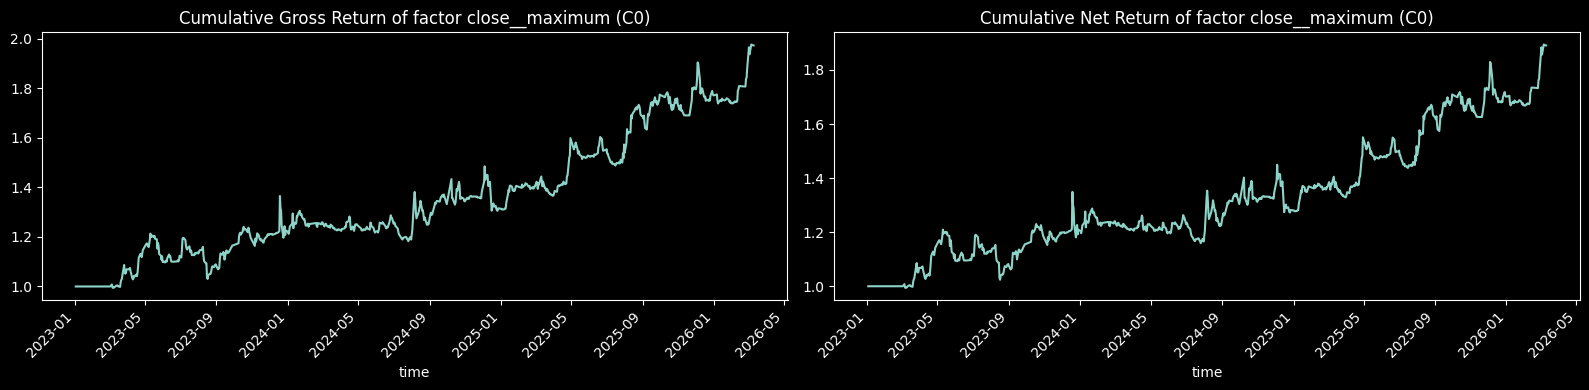

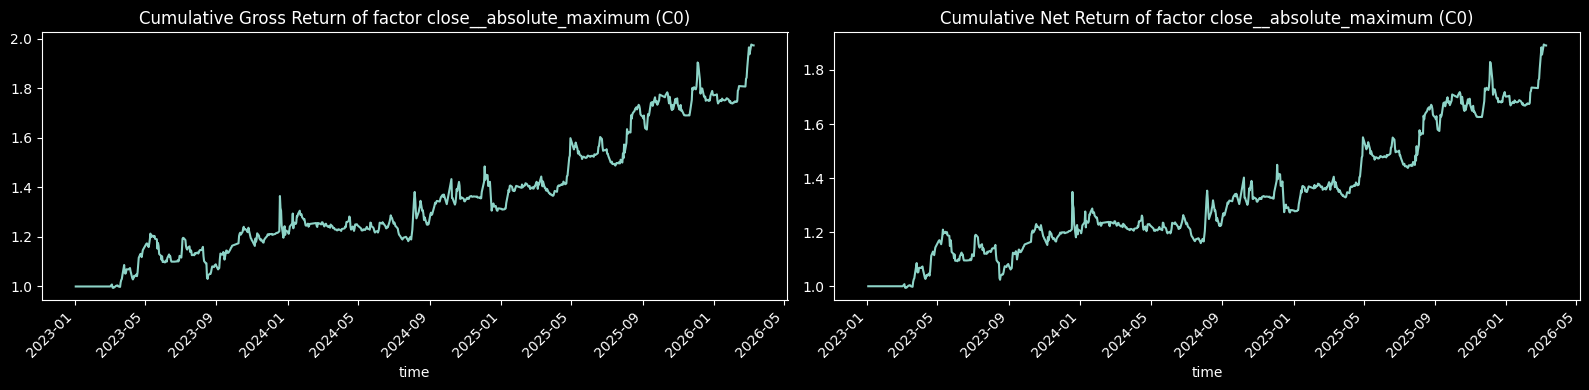

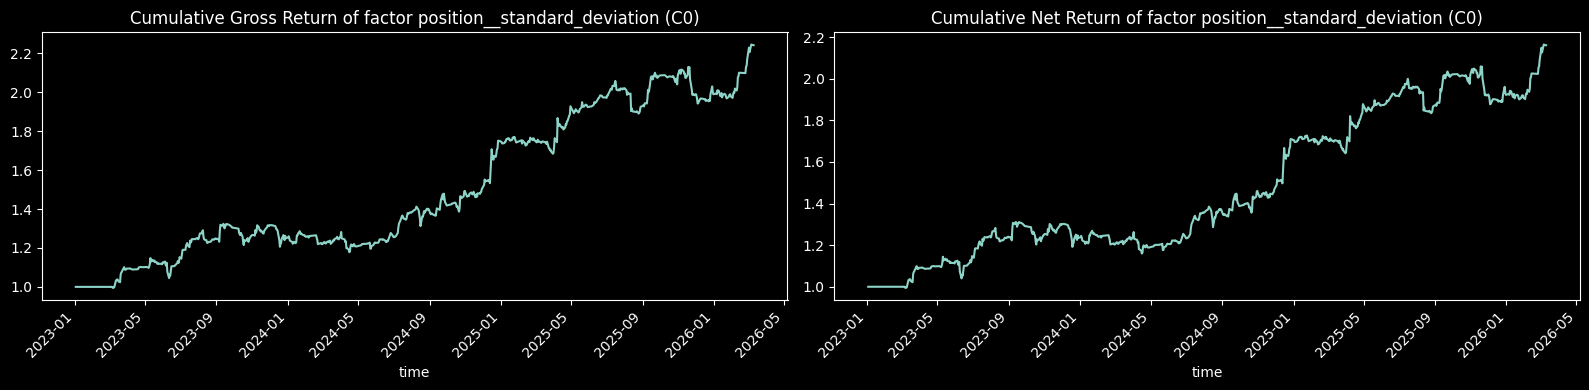

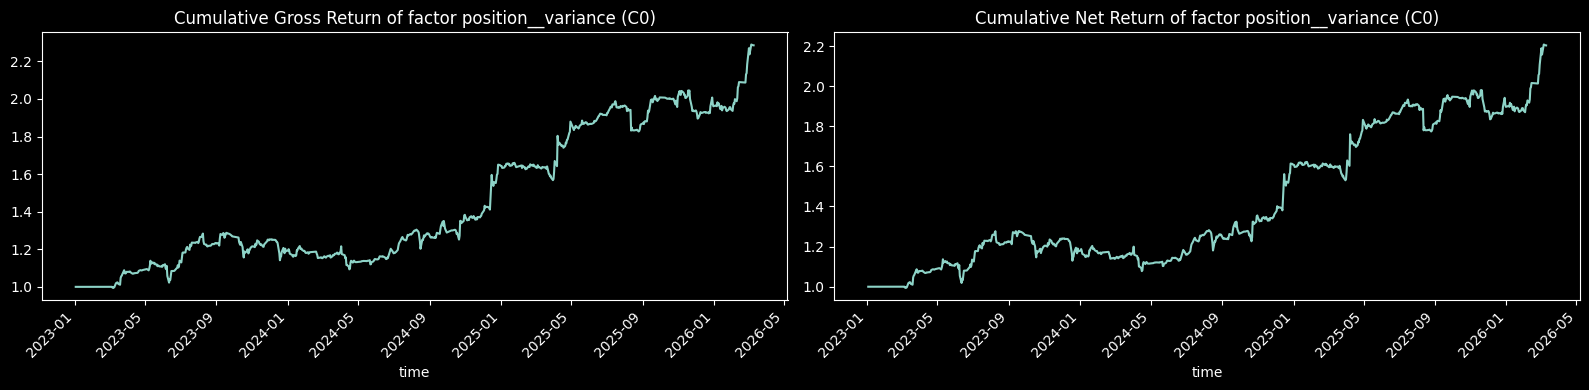

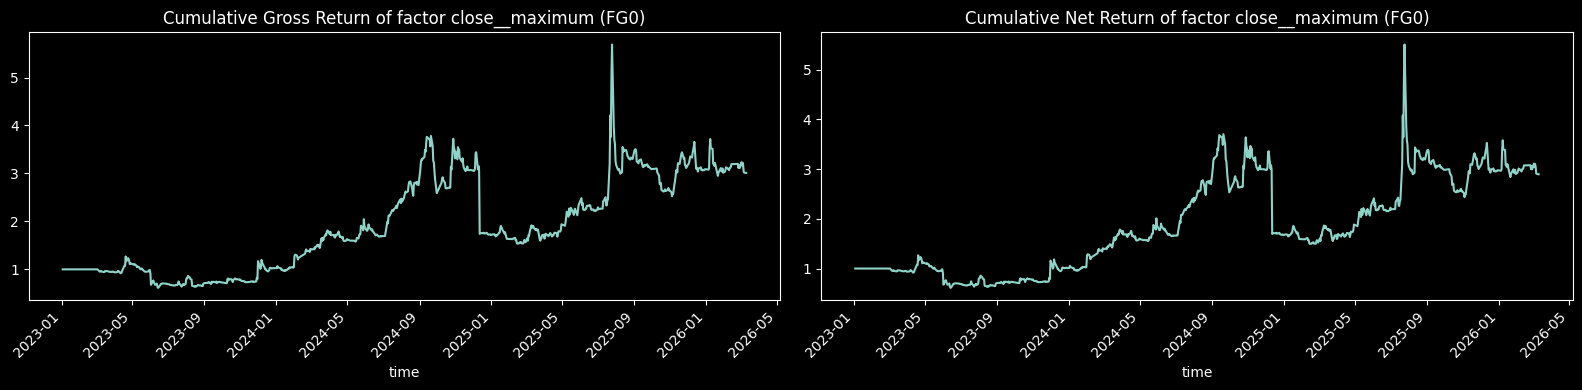

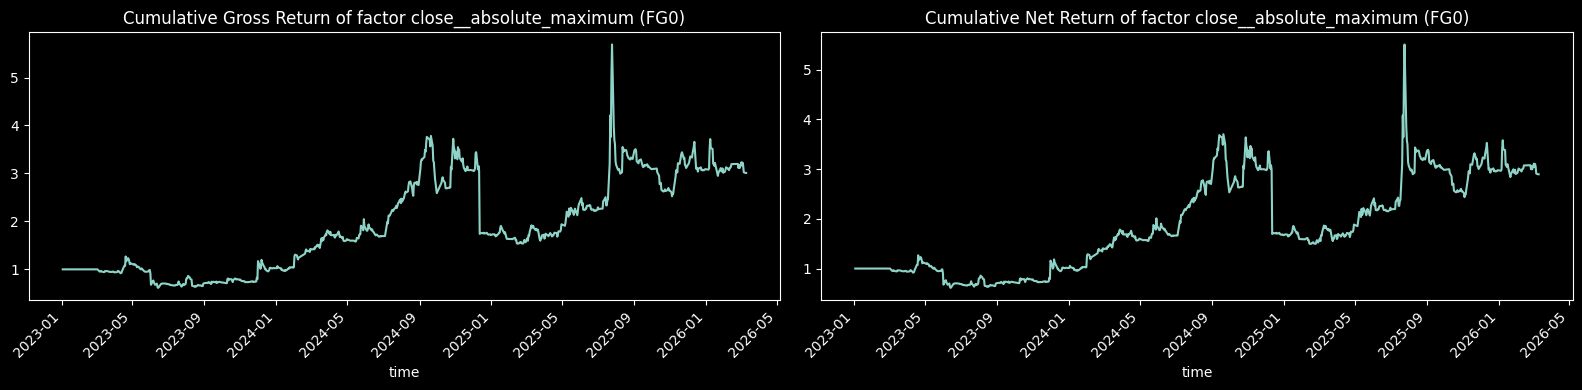

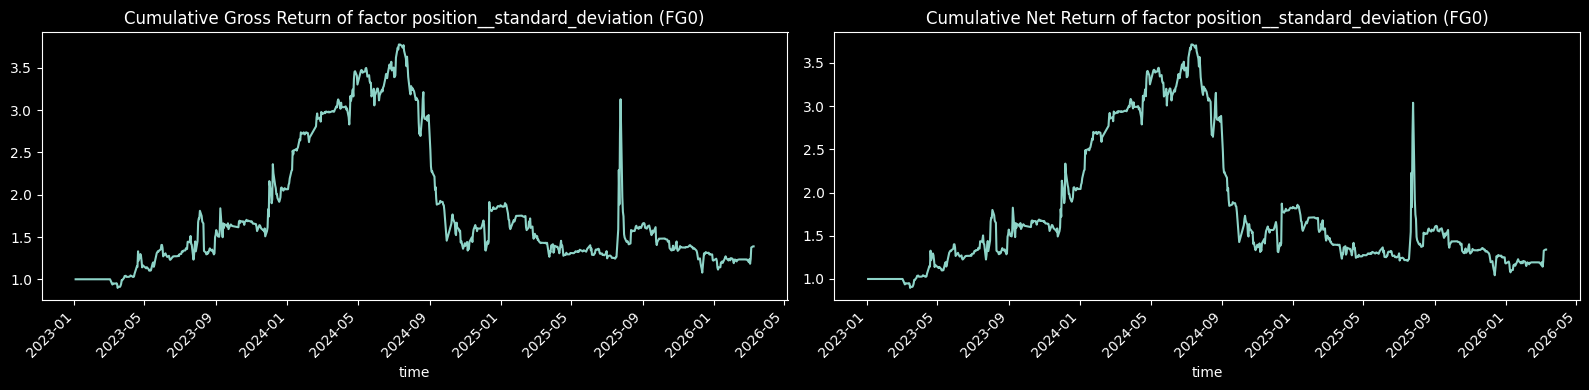

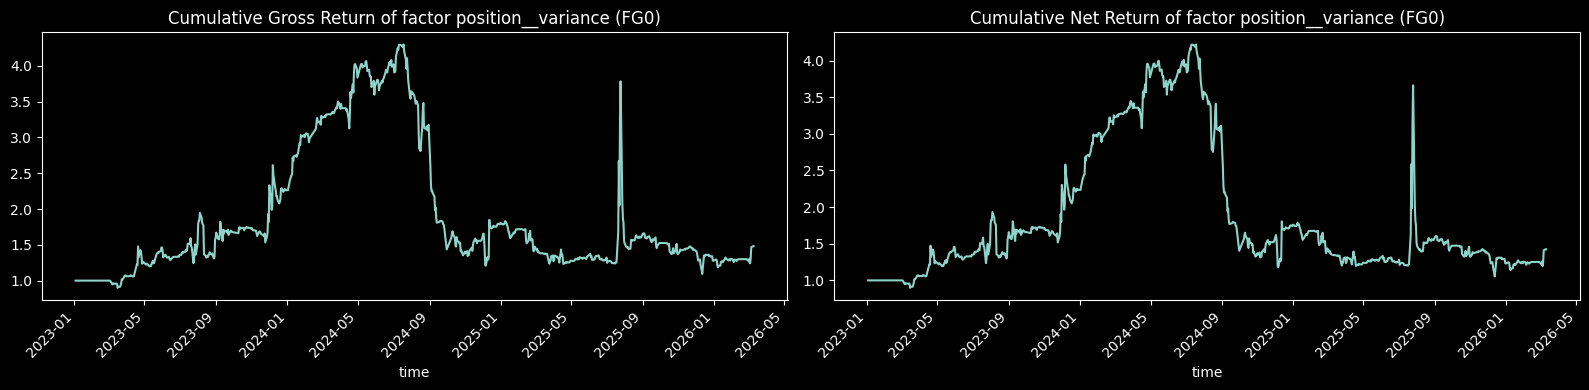

In [11]:
bt2.plot_nav()

# auto search

## 开始search

In [2]:
from factors.factor_auto_search import FactorGenerator
fg = FactorGenerator(
    method='tsfresh',
    instrument_id_list=['C0'],
    fc_freq='1d',
    start_time='20230101',
    end_time='20260310',
    min_window_size=20,
    max_factor_count=20000,
    tsfresh_profile='comprehensive',
    n_jobs=5,
    apply_rolling_norm=True,
    rolling_norm_window=30,
    rolling_norm_min_periods=20
)
# one-step: mine + filter + save high-quality config
result = fg.auto_mine_select_and_save_fc(
    net_ret_threshold=0.05,
    sharpe_threshold=0.8,
    fc_package_name='tsfresh_high_quality_fc_20260317_new',
    require_all_instruments=False
)

/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/wenglongao/anaconda3/envs/future/lib/pytho

In [ ]:
# 全部生成的因子
print("全部生成的因子: ", fg.generated_fc_name_list)
print("选中的因子: ", result['selected_fc_name_list'])
print("计算出的因子值: ", fg.generated_data.head(10))
print("选中因子的回测结果: ", result['bt'].performance_summary)
print("选中因子的净值曲线: ", result['bt'].plot_nav())

## 检查信息泄露

In [ ]:
leakage_check = fg.check_if_leakage(fc_name_list=result['selected_fc_name_list'], raise_error=True)

In [3]:
result.keys()

dict_keys(['config_path', 'selected_fc_name_list', 'bt'])

In [5]:
result['selected_fc_name_list']

['position__standard_deviation',
 'position__variance',
 'position__change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.0',
 'position__change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.8',
 'position__fft_coefficient__attr_"abs"__coeff_1',
 'position__agg_linear_trend__attr_"slope"__chunk_len_5__f_agg_"max"']

In [32]:
fg.generated_data['close__mean_second_derivative_central']

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
         ...   
763   -0.080916
764    0.747108
765    0.904322
766   -0.268384
767   -1.071977
Name: close__mean_second_derivative_central, Length: 768, dtype: float64

In [4]:
df_ps = result['bt'].performance_summary
df_ps.loc[(df_ps['Instrument ID'] == 'C0') & (df_ps['Factor Name'].isin(result['selected_fc_name_list'])]

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Turnover,TS IC,TS RankIC,T-corr,count,all,Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.052574,0.004227,0.107583,0.107586,0.488684,0.039287,0.574831,0.047363,0.085083,0.102389,...,0.932985,0.033609,0.028870,15.556349,1.0,NaN,close__mean_second_derivative_central,1d,0.0002,C0
2024,0.040470,-0.015662,0.123962,0.124316,0.326469,-0.125989,0.338743,-0.135152,0.082009,0.097233,...,1.102895,0.024120,0.060327,15.556349,1.0,NaN,close__mean_second_derivative_central,1d,0.0002,C0
2025,-0.045109,-0.099750,0.094875,0.095080,-0.475457,-1.049119,-0.740100,-1.649765,0.118284,0.161093,...,1.173657,-0.026366,-0.075413,15.588457,1.0,NaN,close__mean_second_derivative_central,1d,0.0002,C0
2026,-0.025127,-0.071756,0.082716,0.083267,-0.303772,-0.861758,-0.443167,-1.268576,0.038553,0.043740,...,1.023425,-0.121442,-0.198988,6.403124,1.0,NaN,close__mean_second_derivative_central,1d,0.0002,C0
all,0.011617,-0.041400,0.108029,0.108243,0.107536,-0.382475,0.127901,-0.469511,0.155871,0.216009,...,1.067503,0.010040,0.001131,768.000000,NaN,NaN,close__mean_second_derivative_central,1d,0.0002,C0


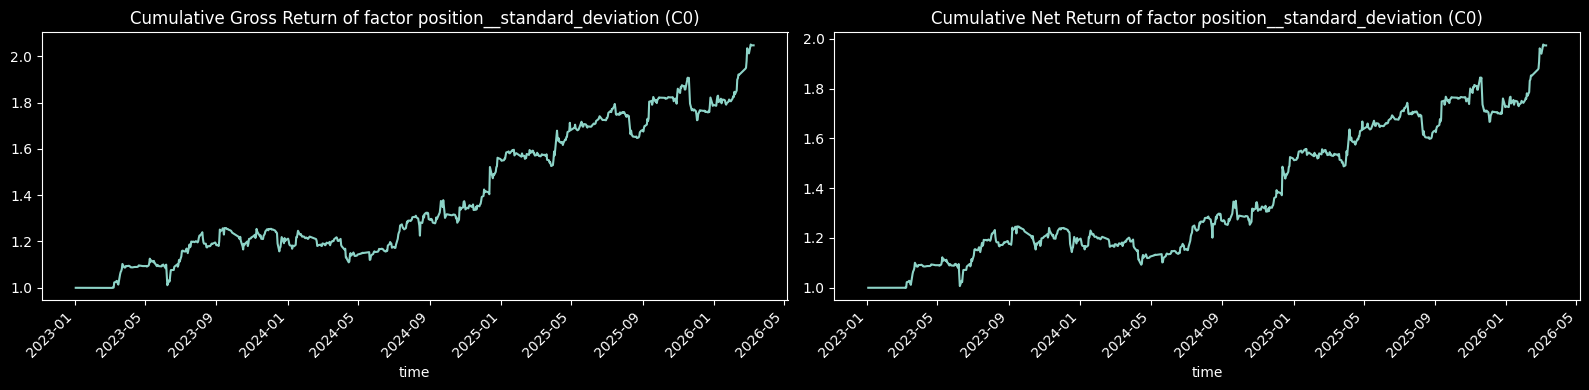

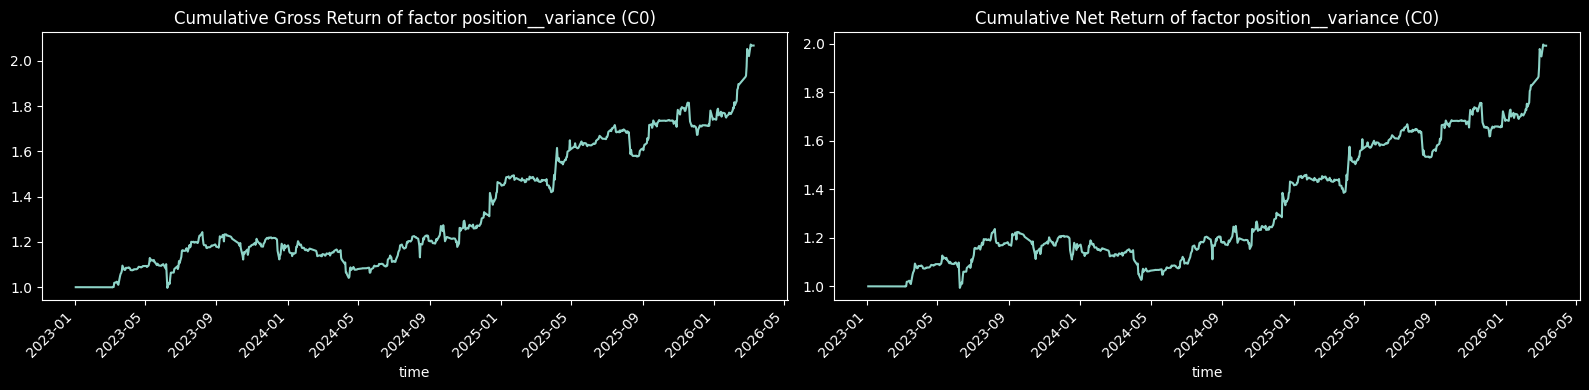

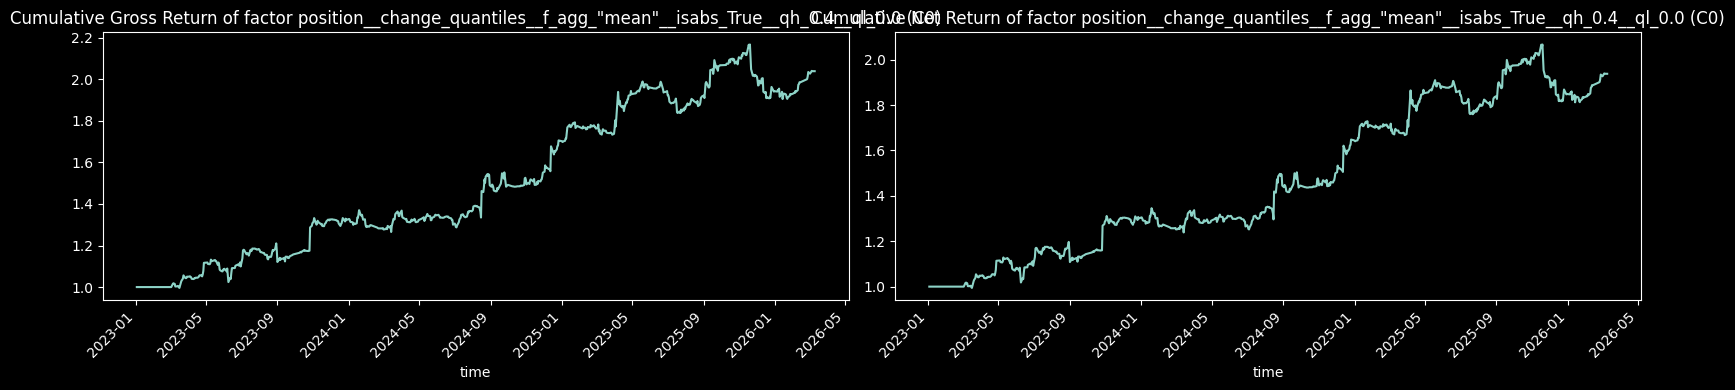

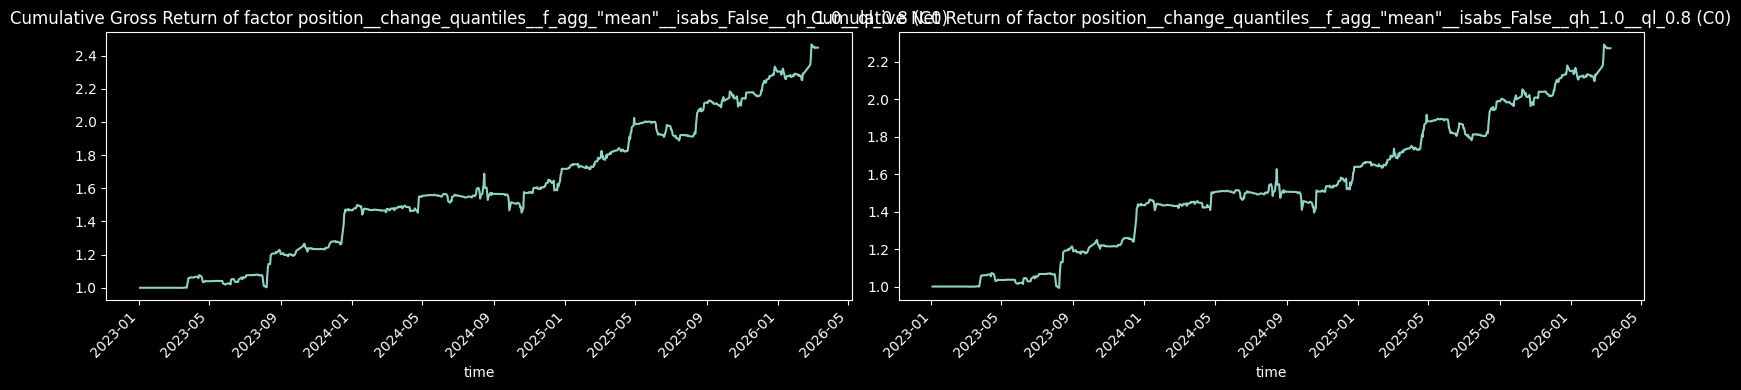

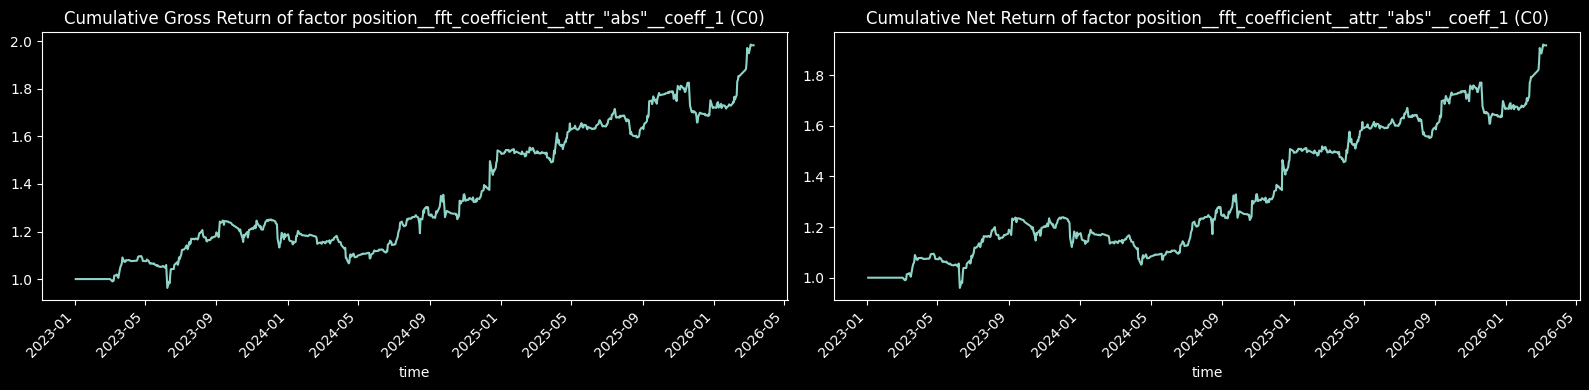

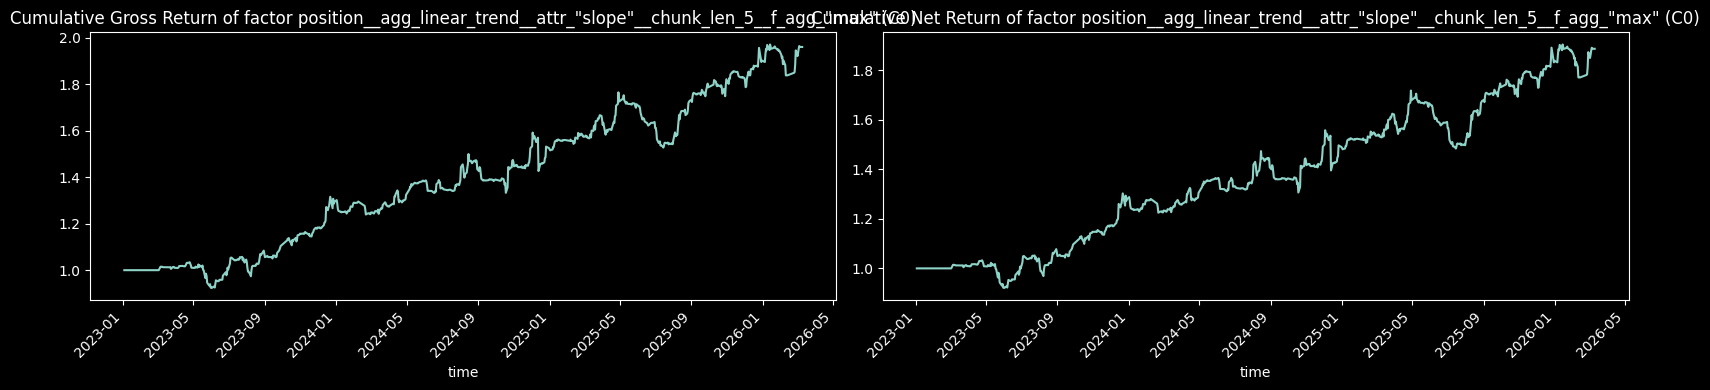

In [6]:
result['bt'].plot_nav(fc_name=result['selected_fc_name_list'])

In [20]:
import numpy as np
import pandas as pd
x = np.array([-3, 7, 3, 4, 5, 6, 7, 8, 9, 20])
x = np.asarray(x)
(x[-1] - x[-2] - x[1] + x[0]) / (2 * (len(x) - 2)) if len(x) > 2 else np.nan

np.float64(0.0625)

In [23]:
x

array([-3,  7,  3,  4,  5,  6,  7,  8,  9, 20])

In [25]:
(pd.Series(x).shift(-2) - pd.Series(x).shift(-1)) / pd.Series(x).shift(-1)

0   -0.571429
1    0.333333
2    0.250000
3    0.200000
4    0.166667
5    0.142857
6    0.125000
7    1.222222
8         NaN
9         NaN
dtype: float64

In [26]:
pd.Series(x).pct_change().shift(-2)

0   -0.571429
1    0.333333
2    0.250000
3    0.200000
4    0.166667
5    0.142857
6    0.125000
7    1.222222
8         NaN
9         NaN
dtype: float64

In [5]:
result['bt'].fc_name_with_param_list

['close__has_duplicate_max',
 'close__has_duplicate_min',
 'close__has_duplicate',
 'close__sum_values',
 'close__abs_energy',
 'close__mean_abs_change',
 'close__mean_change',
 'close__mean_second_derivative_central',
 'close__median',
 'close__mean',
 'close__standard_deviation',
 'close__variation_coefficient',
 'close__variance',
 'close__skewness',
 'close__kurtosis',
 'close__root_mean_square',
 'close__absolute_sum_of_changes',
 'close__longest_strike_below_mean',
 'close__longest_strike_above_mean',
 'close__count_above_mean',
 'close__count_below_mean',
 'close__last_location_of_maximum',
 'close__first_location_of_maximum',
 'close__last_location_of_minimum',
 'close__first_location_of_minimum',
 'close__percentage_of_reoccurring_values_to_all_values',
 'close__percentage_of_reoccurring_datapoints_to_all_datapoints',
 'close__sum_of_reoccurring_values',
 'close__sum_of_reoccurring_data_points',
 'close__ratio_value_number_to_time_series_length',
 'close__sample_entropy',
 'cl

In [24]:
result['performance_summary']

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Turnover,TS IC,TS RankIC,T-corr,count,all,Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.063175,0.061746,0.042730,0.042817,1.478472,1.442114,1.582395,1.566200,0.023179,0.023179,...,0.026604,0.062032,0.054474,15.556349,1.0,NaN,close__has_duplicate_max,1d,0.0002,C0
2024,-0.111929,-0.117198,0.072152,0.073384,-1.551310,-1.597051,-0.676623,-0.711863,0.108051,0.113134,...,0.116138,-0.098367,-0.138366,15.556349,1.0,NaN,close__has_duplicate_max,1d,0.0002,C0
2025,-0.048782,-0.051477,0.056786,0.057598,-0.859058,-0.893734,-0.552064,-0.591190,0.062199,0.063804,...,0.055324,-0.050575,-0.041203,15.588457,1.0,NaN,close__has_duplicate_max,1d,0.0002,C0
2026,0.168835,0.132575,0.062699,0.060042,2.692781,2.208039,10.944321,8.242168,0.005425,0.006566,...,0.628726,0.056783,0.002664,6.403124,1.0,NaN,close__has_duplicate_max,1d,0.0002,C0
all,-0.025234,-0.029978,0.058818,0.059409,-0.429026,-0.504605,-0.259133,-0.311544,0.162544,0.168771,...,0.096048,-0.025162,-0.040754,768.000000,NaN,NaN,close__has_duplicate_max,1d,0.0002,C0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,-0.404488,-0.419383,0.519133,0.518465,-0.779160,-0.808894,-1.040695,-1.091084,0.539030,0.544103,...,0.506137,-0.059183,-0.101863,15.556349,1.0,NaN,"close__change_quantiles__f_agg_""var""__isabs_Fa...",1d,0.0002,FG0
2024,-0.073596,-0.097919,0.559004,0.559160,-0.131656,-0.175118,-0.135347,-0.183196,0.353598,0.364395,...,0.524957,0.013351,0.075216,15.556349,1.0,NaN,"close__change_quantiles__f_agg_""var""__isabs_Fa...",1d,0.0002,FG0
2025,-0.553310,-0.566089,1.042812,1.041683,-0.530594,-0.543437,-0.556803,-0.584045,0.738960,0.740744,...,0.579153,-0.018172,-0.069305,15.588457,1.0,NaN,"close__change_quantiles__f_agg_""var""__isabs_Fa...",1d,0.0002,FG0
